In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

In [2]:
DATA_PATH = "../data/processed/cleaned_advertising.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
print(df.shape)

display(df.head())

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
display(df.describe())

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


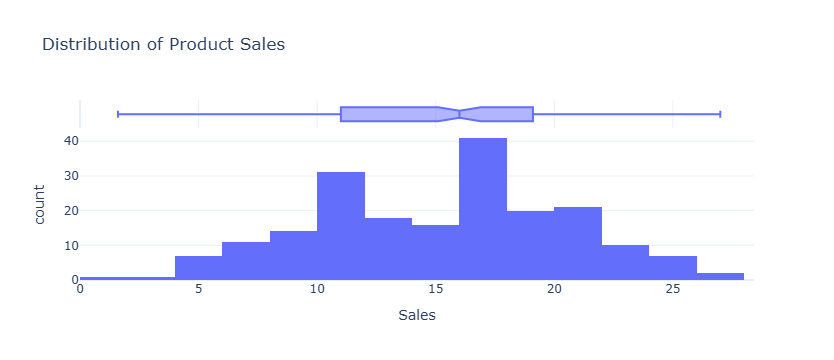

In [5]:
fig = px.histogram(
    df,
    x="Sales",
    nbins=20,
    title="Distribution of Product Sales",
    marginal="box",
    template="plotly_white"
)

fig.show()

In [7]:
### Observation

#Sales values are distributed across a broad range.
#The distribution appears relatively balanced without extreme skewness.
#No obvious anomalies are visible.

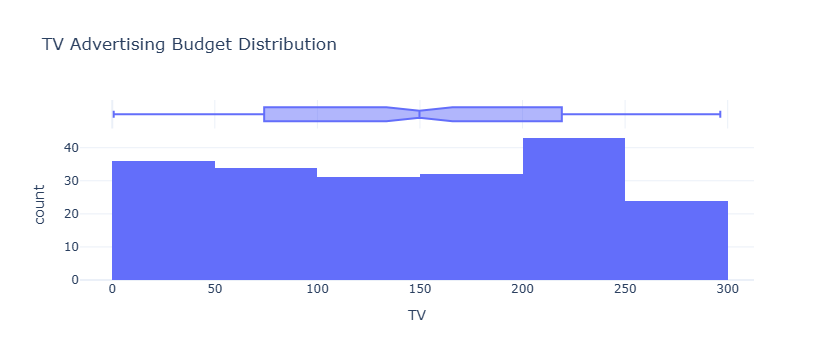

In [8]:
fig = px.histogram(
    df,
    x="TV",
    title="TV Advertising Budget Distribution",
    marginal="box",
    template="plotly_white"
)

fig.show()

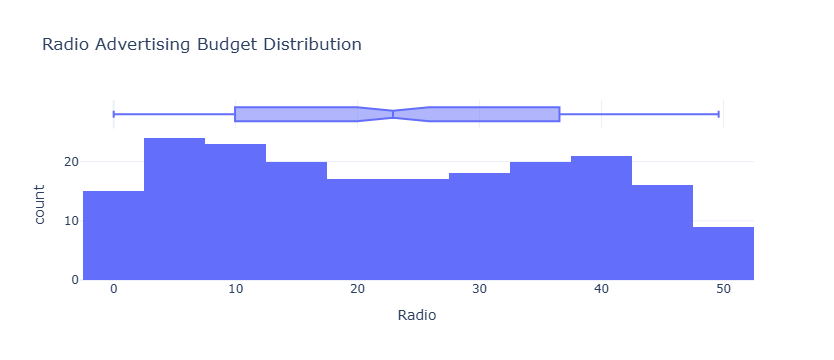

In [9]:
fig = px.histogram(
    df,
    x="Radio",
    title="Radio Advertising Budget Distribution",
    marginal="box",
    template="plotly_white"
)

fig.show()

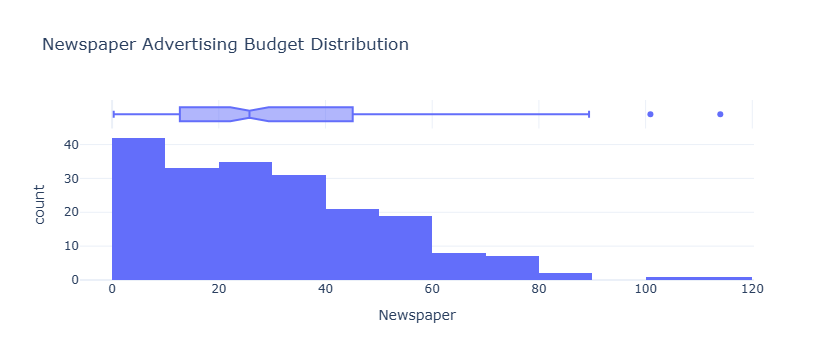

In [10]:
fig = px.histogram(
    df,
    x="Newspaper",
    title="Newspaper Advertising Budget Distribution",
    marginal="box",
    template="plotly_white"
)

fig.show()

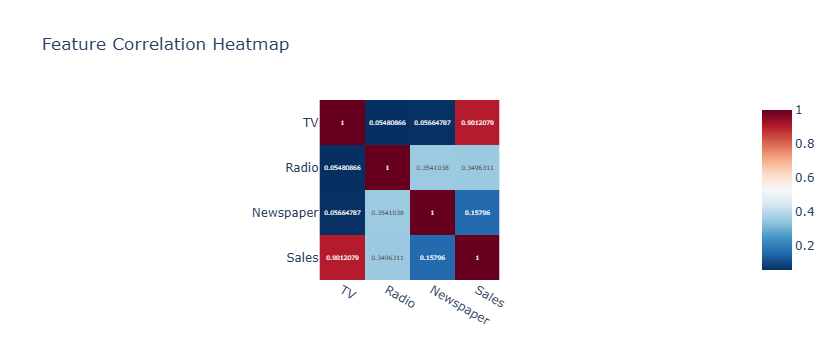

In [11]:
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Feature Correlation Heatmap"
)

fig.show()

In [12]:
### Observation

#TV expenditure shows the strongest positive relationship with Sales.
#Radio expenditure also demonstrates a positive correlation with Sales.
#Newspaper expenditure exhibits a relatively weak relationship with Sales.

In [22]:
# ============================================================
# Correlation of Advertising Channels with Sales
# ============================================================

sales_correlation = (
    df.corr(numeric_only=True)["Sales"]
    .drop("Sales")
    .sort_values(ascending=False)
    .reset_index()
)

sales_correlation.columns = ["Advertising Channel", "Correlation with Sales"]

display(
    sales_correlation.style
    .format({"Correlation with Sales": "{:.3f}"})
)

,Advertising Channel,Correlation with Sales
0,TV,0.901
1,Radio,0.350
2,Newspaper,0.158


In [23]:
### Observation

#TV advertising has the strongest correlation with sales.
#Radio advertising has a moderate positive relationship with sales.
#Newspaper advertising shows the weakest relationship with sales.
#These results suggest that TV and Radio are likely to be more useful predictors in the machine learning models.

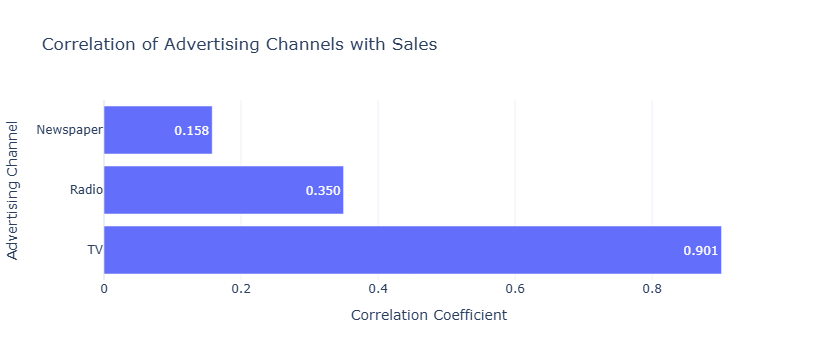

In [24]:
# ============================================================
# Correlation Bar Chart
# ============================================================

fig = px.bar(
    sales_correlation,
    x="Correlation with Sales",
    y="Advertising Channel",
    orientation="h",
    text_auto=".3f",
    title="Correlation of Advertising Channels with Sales",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Correlation Coefficient",
    yaxis_title="Advertising Channel"
)

fig.show()

In [25]:
### Observation

#The correlation bar chart makes it easier to compare the relative strength of each advertising channel. TV clearly has the strongest relationship with sales, while Newspaper contributes comparatively little.

In [26]:
# ============================================================
# Total Advertising Spend by Channel
# ============================================================

total_spend = pd.DataFrame({
    "Advertising Channel": ["TV", "Radio", "Newspaper"],
    "Total Spend": [
        df["TV"].sum(),
        df["Radio"].sum(),
        df["Newspaper"].sum()
    ]
})

display(total_spend)

,Advertising Channel,Total Spend
0,TV,29408.5
1,Radio,4652.8
2,Newspaper,6110.8


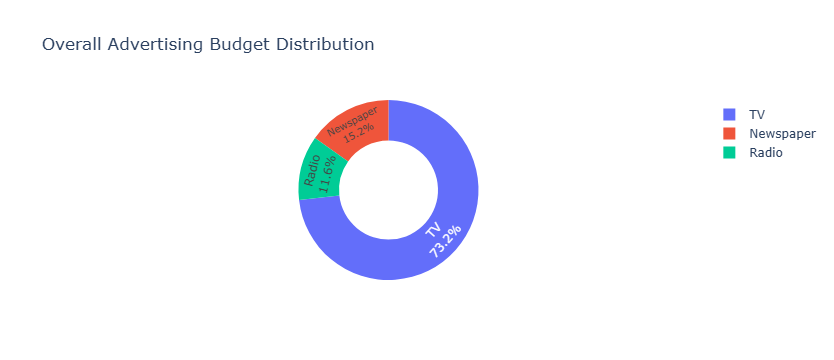

In [27]:
# ============================================================
# Advertising Spend Donut Chart
# ============================================================

fig = px.pie(
    total_spend,
    names="Advertising Channel",
    values="Total Spend",
    hole=0.55,
    title="Overall Advertising Budget Distribution",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

In [28]:
### Observation

#TV receives the largest share of the overall advertising budget.
#Radio and Newspaper account for smaller proportions of total spending.
#Since TV also has the strongest relationship with sales, the dataset suggests that businesses allocate more budget to the channel that appears to generate the greatest sales impact.
#However, correlation alone does not prove return on investment, so model coefficients and prediction-based what-if analysis will be examined later.

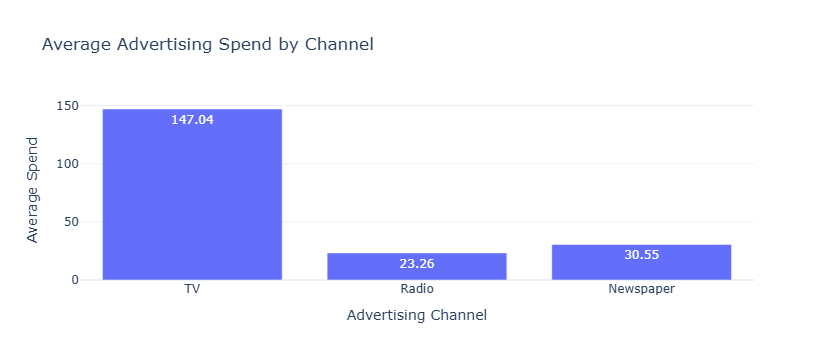

In [29]:
# ============================================================
# Average Advertising Spend by Channel
# ============================================================

average_spend = pd.DataFrame({
    "Advertising Channel": ["TV", "Radio", "Newspaper"],
    "Average Spend": [
        df["TV"].mean(),
        df["Radio"].mean(),
        df["Newspaper"].mean()
    ]
})

fig = px.bar(
    average_spend,
    x="Advertising Channel",
    y="Average Spend",
    text_auto=".2f",
    title="Average Advertising Spend by Channel",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Advertising Channel",
    yaxis_title="Average Spend"
)

fig.show()

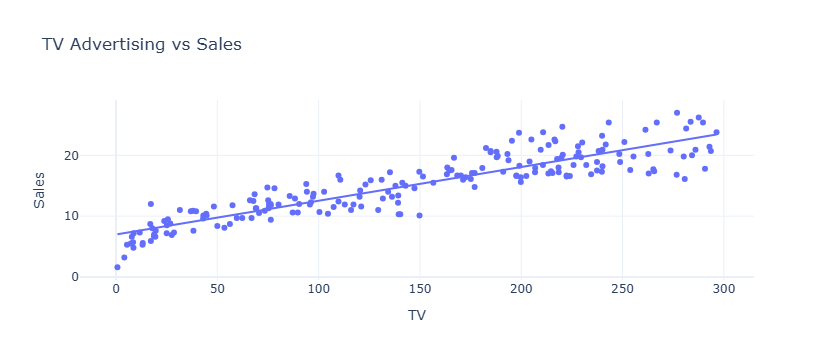

In [13]:
fig = px.scatter(
    df,
    x="TV",
    y="Sales",
    trendline="ols",
    title="TV Advertising vs Sales",
    template="plotly_white"
)

fig.show()

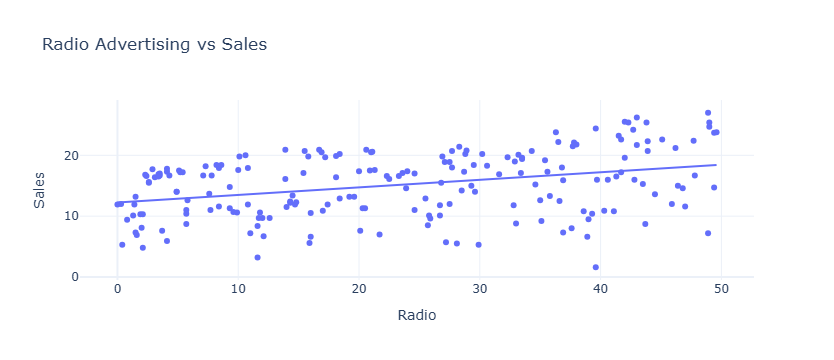

In [14]:
fig = px.scatter(
    df,
    x="Radio",
    y="Sales",
    trendline="ols",
    title="Radio Advertising vs Sales",
    template="plotly_white"
)

fig.show()

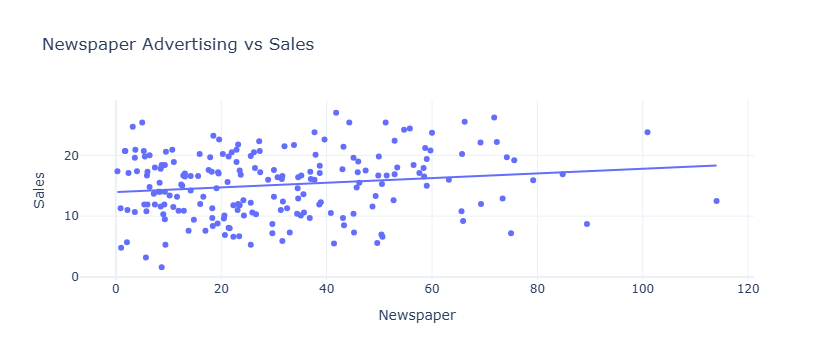

In [15]:
fig = px.scatter(
    df,
    x="Newspaper",
    y="Sales",
    trendline="ols",
    title="Newspaper Advertising vs Sales",
    template="plotly_white"
)

fig.show()

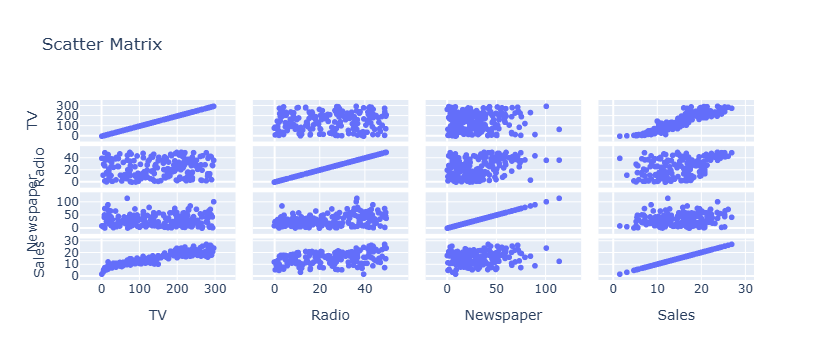

In [16]:
fig = px.scatter_matrix(
    df,
    dimensions=["TV","Radio","Newspaper","Sales"],
    title="Scatter Matrix",
)

fig.show()

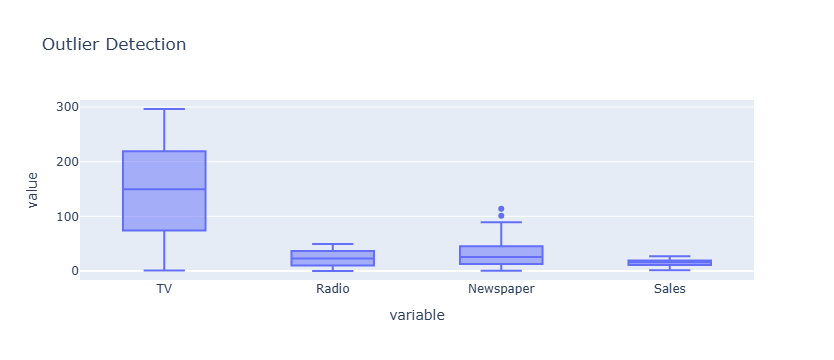

In [17]:
fig = px.box(
    df,
    y=["TV","Radio","Newspaper","Sales"],
    title="Outlier Detection"
)

fig.show()

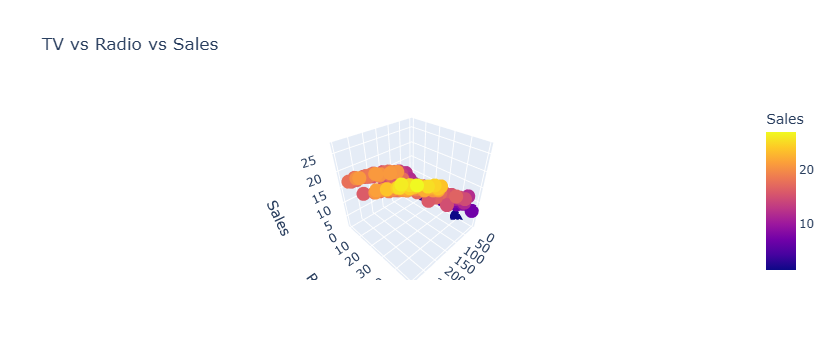

In [18]:
fig = px.scatter_3d(
    df,
    x="TV",
    y="Radio",
    z="Sales",
    color="Sales",
    title="TV vs Radio vs Sales"
)

fig.show()

In [21]:
# Business Insights

### TV Advertising

#TV advertising demonstrates the strongest positive relationship with product sales, suggesting that increased investment in television campaigns generally contributes to higher sales performance.



### Radio Advertising

#Radio advertising also exhibits a positive relationship with sales, although its impact appears to be lower than television advertising.



### Newspaper Advertising

#Compared to TV and Radio, newspaper advertising shows only a weak relationship with sales. This indicates that increasing newspaper advertising expenditure alone may not significantly improve product sales.


### Advertising Strategy

#Organizations aiming to maximize sales should prioritize investments in TV advertising while using Radio advertising to complement marketing campaigns. Newspaper advertising may require careful evaluation to ensure a positive return on investment.